# PROJECT: Quantum Dot Simulation
by Szymon Waliczek
- Simulation of a 2D semiconductor quantum dot (CdSe)
- Analysis of energy levels using ARPACK solver
- Mapping of energy transitions to the visible spectrum (color)
- Numerical method: Tight-binding discretization on a square lattice

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [2]:
import kwant
import numpy as np
from matplotlib import pyplot as plt
from scipy.sparse.linalg import eigsh
from matplotlib.colors import LinearSegmentedColormap

In [29]:
# Stałe fizyczne dla CdSe (QLED standard)
from scipy.constants import physical_constants
eV = physical_constants['electron volt'][0]
m_el = physical_constants['electron mass'][0]
h_bar = physical_constants['Planck constant over 2 pi'][0]
m_eff = 0.13 * m_el

# Parametry sieciowe
Eg_CdSe = 1.74  # eV (przerwa wzbroniona CdSe bulk)
a = 0.05  #  2 Angstrem
t = (h_bar**2 / (2*m_eff*(a * 1e-9)**2)) / eV # Energia przeskoku w eV

In [30]:
def onsite(site, V):
    return 4*t + V

def make_quantum_dot(a, R):
    # Funkcja kształtu - okrągła kropka o promieniu R
    def circle(pos):
        x, y = pos
        return x**2 + y**2 < R**2
    lat = kwant.lattice.square(a, norbs=1)
    sys = kwant.Builder()
    sys[lat.shape(circle, (0, 0))] = onsite
    sys[lat.neighbors()] = -t
    return sys.finalized()

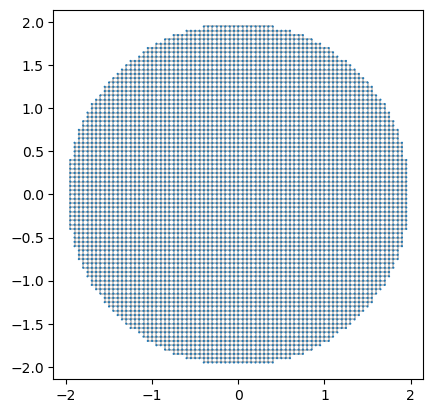

In [32]:
R_test = 2.0 # nm
dot_sys = make_quantum_dot(a=0.05, R=R_test)
kwant.plot(dot_sys);

In [33]:
def compute_dot_spectrum(sys, V):
    params = dict(V=V)
    H = sys.hamiltonian_submatrix(params=params, sparse=True)
    N = H.shape[0]
    k_num = N - 2
    # Metoda Lanczosa (ARPACK) zwraca wartosci (evals) i macierz wektorow (evecs)
    evals, evecs = eigsh(H, k=k_num, which='SA')
    idx = evals.argsort()
    return evals[idx], evecs[:, idx]

def compute_dot_spectrum_0(sys, n, V):
    params = dict(V=V)
    H = sys.hamiltonian_submatrix(params=params, sparse=True)
    evals, evecs = eigsh(H, k=n, which='SA')
    idx = evals.argsort()
    return evals[idx], evecs[:, idx]

def plot_probability_density(sys, v, level):
    rho = np.abs(evecs[:, level])**2
    kwant.plotter.map(sys, rho, method='linear', cmap='inferno', oversampling=1)

In [34]:
evals, evecs = compute_dot_spectrum(dot_sys, 0)


KeyboardInterrupt



In [ ]:
# Obliczenie energii przejścia i koloru (E1 - E0 + Eg)
Ef = (evals[1] - evals[0]) + Eg_CdSe
wavelength_test = 1240 / Ef # nm
print(f"Emitowana długość fali: {wavelength_test:.2f} nm")

In [ ]:
plot_probability_density(sys=dot_sys, v=evecs, level=0)

In [ ]:
def wl_to_rgb(wavelength):
    w = float(wavelength)
    if 380 <= w <= 440: R, G, B = -(w - 440) / 60, 0.0, 1.0
    elif 440 <= w <= 490: R, G, B = 0.0, (w - 440) / 50, 1.0
    elif 490 <= w <= 510: R, G, B = 0.0, 1.0, -(w - 510) / 20
    elif 510 <= w <= 580: R, G, B = (w - 510) / 70, 1.0, 0.0
    elif 580 <= w <= 645: R, G, B = 1.0, -(w - 645) / 65, 0.0
    elif 645 <= w <= 780: R, G, B = 1.0, 0.0, 0.0
    else: R, G, B = 0.0, 0.0, 0.0
    return (R, G, B)

def get_phys_cmap(wavelength): #Tworzy mape kolorów od czerni do fizycznego koloru emisji
    rgb = wl_to_rgb(wavelength)
    return LinearSegmentedColormap.from_list("dot_cmap", [(0,0,0), rgb])

def plot_multiple_dots(_a, _R, _n, _V):
    fig, axes = plt.subplots(1, len(_R), figsize=(15, 5))
    
    for i, r in enumerate(_R):
        sys = make_quantum_dot(_a, r)
        evals, evecs = compute_dot_spectrum_0(sys, _n, _V) # Tylko stan podstawowy (k=1)
        E_phot = Eg_CdSe + evals[0] # Energia fotonu = przerwa materiałowa + energia uwięzienia
        wavelength = 1240 / E_phot
        rho = np.abs(evecs[:, 0])**2 # Gęstość prawdopodobieństwa odpowiada za lokalną intensywność świecenia
        cmap = get_phys_cmap(wavelength)
        
        # Rysowanie mapy gęstości z fiycznym kolorem
        kwant.plotter.map(sys, rho, cmap=cmap, ax=axes[i], colorbar=False)
        axes[i].set_title(f"R = {_R[i]}nm\n$\lambda$ = {wavelength:.1f}nm")
        axes[i].axis('off')
    
    plt.tight_layout()

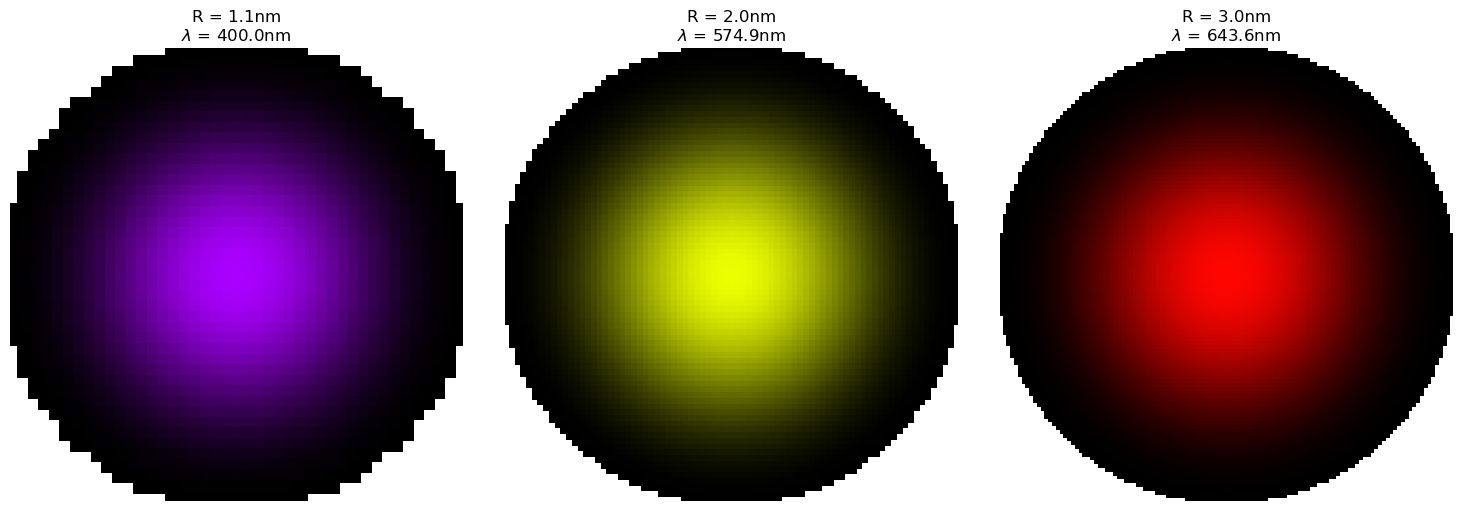

In [35]:
plot_multiple_dots(_a=0.05, _R=[1.1, 2.0, 3.0], _n=1, _V=0)

In [12]:
import matplotlib.cm as cm

def plot_color_shift_curve(_a, r_min, r_max, steps):
    _R = np.linspace(r_min, r_max, steps)
    wavelengths = []
    
    for r in _R:
        sys = make_quantum_dot(a=_a, R=r)
        evals, _ = compute_dot_spectrum_0(sys, 1, 0)
        E_phot = Eg_CdSe + evals[0]
        wavelengths.append(1240 / E_phot)
    
    plt.figure(figsize=(10, 6))
    for i in range(len(_R)-1): # Rysujemy linię, ale punkty kolorujemy zgodnie z wyliczoną lambdą
        color = wl_to_rgb(wavelengths[i])
        plt.plot(_R[i:i+2], wavelengths[i:i+2], color=color, linewidth=4)
        
    plt.xlabel('Promień kropki R [nm]')
    plt.ylabel('Długość fali $\lambda$ [nm]')
    plt.title('Efekt uwięzienia kwantowego: Zmiana koloru vs Rozmiar')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Dodanie kolorowego paska widma dla referencji
    for w in range(380, 750):
        plt.axhspan(w, w+1, color=wl_to_rgb(w), alpha=0.1, zorder=0)
        
    plt.tight_layout()
    plt.savefig("color_shift_analysis.png")

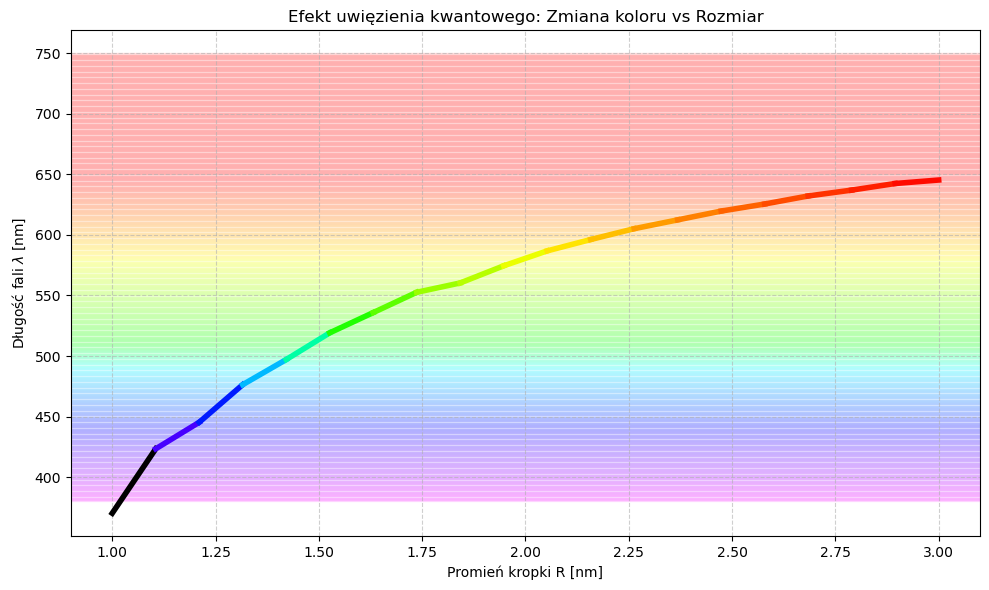

In [13]:
# Uruchomienie dla zakresu, który pokaże zmianę od niebieskiego do czerwonego
plot_color_shift_curve(_a=0.2, r_min=1, r_max=3, steps=20)